# 6 · Temporal products & statistical series

`TimeSeries` / `Climatology` over a `DatasetCollection`, and the `series` helpers (`envelope`, `quantile_band`, `boxplot`, `multiboxplot`, `stripes`).

In [1]:
%matplotlib inline
from pathlib import Path

# Resolve the repo root so the bundled sample DEM is found whether this runs from
# docs/examples/ (mkdocs) or the repository root.
ROOT = Path.cwd()
while not (ROOT / "examples" / "data" / "LisbonElevation.tif").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DEM = str(ROOT / "examples" / "data" / "LisbonElevation.tif")
print("DEM:", DEM)

DEM: C:\gdrive\algorithms\Visualization\Digital-Earth\examples\data\LisbonElevation.tif


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pyramids.dataset import Dataset
from pyramids.dataset.collection import DatasetCollection
from digitalearth import series
from digitalearth.temporal import TimeSeries, Climatology

# Build a 12-month synthetic 'snow line' stack by scaling the DEM with a seasonal cycle.
ds = Dataset.read_file(DEM)
z = np.nan_to_num(ds.read_array(band=0).astype('float32'))
rng = np.random.default_rng(0)
members = []
for month in range(12):
    factor = 0.5 + 0.5 * np.cos((month - 1) / 12 * 2 * np.pi)  # winter high, summer low
    arr = (z * factor + rng.normal(0, 5, z.shape)).astype('float32')
    members.append(Dataset.create_from_array(arr=arr, geo=ds.geotransform, epsg=ds.epsg))
dc = DatasetCollection(members[0], len(members), datasets=members)
print('members:', len(dc.datasets))

2026-05-28 20:04:06 | INFO | pyramids.base.config | Logging is configured.


members: 12


## TimeSeries — monthly spatial-mean elevation proxy

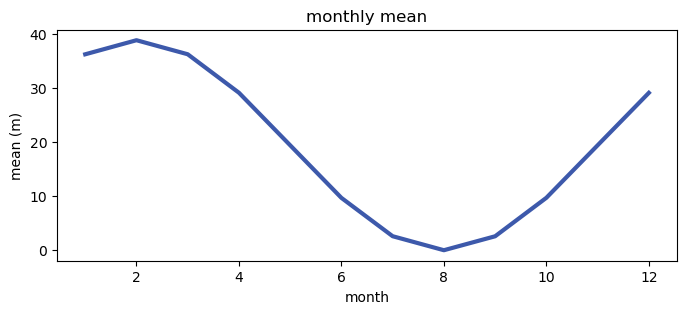

In [3]:
fig, ax = plt.subplots(figsize=(8, 3))
TimeSeries(dc).plot(times=list(range(1, 13)), ax=ax)
ax.set(xlabel='month', ylabel='mean (m)', title='monthly mean')
fig;

## Climatology — seasonal group means + spread plume

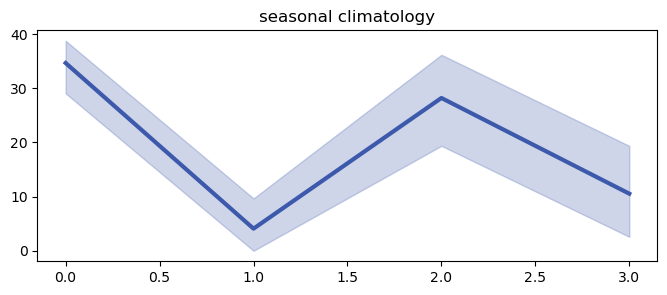

In [4]:
seasons = ['DJF','DJF','MAM','MAM','MAM','JJA','JJA','JJA','SON','SON','SON','DJF']
fig, ax = plt.subplots(figsize=(8, 3))
Climatology(dc, seasons).plot(ax=ax)
ax.set(title='seasonal climatology')
fig;

## Ensemble band (quantiles) and box plots

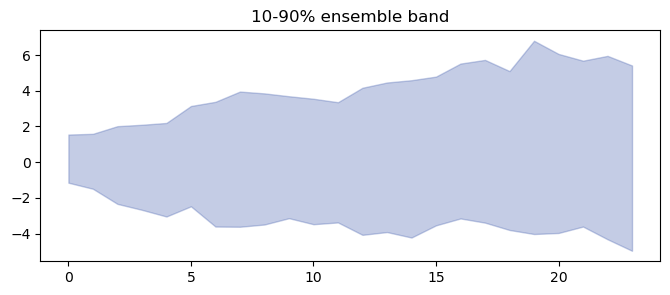

In [5]:
ensemble = rng.normal(size=(40, 24)).cumsum(axis=1)
fig, ax = plt.subplots(figsize=(8, 3))
series.quantile_band(ensemble, lower=0.1, upper=0.9, ax=ax, alpha=0.3)
ax.set_title('10-90% ensemble band')
fig;

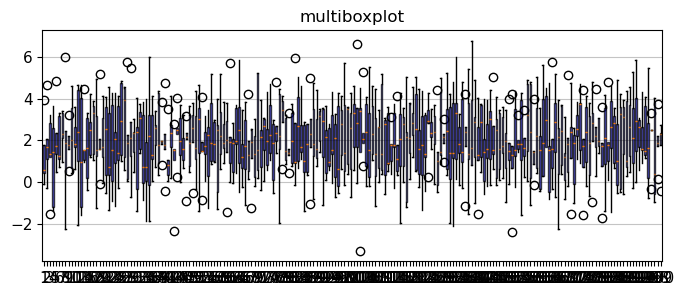

In [6]:
fig, ax = plt.subplots(figsize=(8, 3))
series.multiboxplot([rng.normal(m, 1, 200) for m in range(5)], ax=ax)
ax.set_title('multiboxplot')
fig;

## Warming stripes

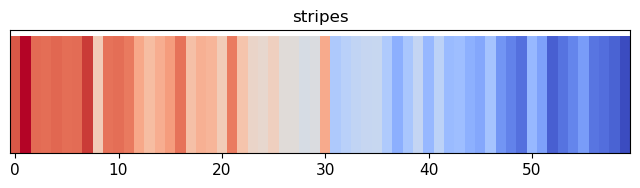

In [7]:
fig, ax = plt.subplots(figsize=(8, 1.6))
series.stripes(np.linspace(-1, 1, 60) + rng.normal(0, 0.2, 60), ax=ax)
ax.set_title('stripes')
fig;